In [12]:
from langchain_ollama import OllamaLLM
from langgraph.graph import START, StateGraph, MessagesState
from langchain_core.messages import HumanMessage, AIMessage
from typing import Literal

In [13]:
chat = OllamaLLM(
    model="llama3.1:8b",
    temperature=0.5,
    num_predict=100
)

In [14]:
def ask_question(state: MessagesState) -> MessagesState:
    question = "Какой вопрос?"
    return MessagesState(messages = [AIMessage(question), HumanMessage(input(question))])

In [15]:
def chatbot(state: MessagesState) -> MessagesState:
    response = chat.invoke(state["messages"])
    print("Ответ: " + response)
    return MessagesState(messages = [response])

In [16]:
def ask_another_question(state: MessagesState) -> MessagesState:
    question = "Есть еще вопросы (да/нет)?"
    return MessagesState(messages = [AIMessage(question), HumanMessage(input(question))])

In [17]:
def routing_function(state: MessagesState) -> Literal["ask_question", "__end__"]:
    
    if state["messages"][-1].content == "да":
        return "ask_question"
    else:
        return "__end__"

### Define the Graph

In [18]:
graph = StateGraph(MessagesState)

In [19]:
graph.add_node("ask_question", ask_question)
graph.add_node("chatbot", chatbot)
graph.add_node("ask_another_question", ask_another_question)

graph.add_edge(START, "ask_question")
graph.add_edge("ask_question", "chatbot")
graph.add_edge("chatbot", "ask_another_question")
graph.add_conditional_edges(source = "ask_another_question", 
                            path = routing_function)

In [20]:
graph_compiled = graph.compile()

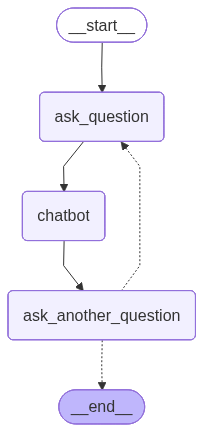

In [21]:
graph_compiled

### Test the Graph

In [22]:
graph_compiled.invoke(MessagesState(messages = []))

TypeError: ask_question() takes 0 positional arguments but 1 was given